# UN SDG 4: Quality Education — Exploratory Data Analysis (EDA) & SQL Queries

**Course**: ETL (G51) — Data Engineering & Artificial Intelligence  
**Institution**: Universidad Autónoma de Occidente (UAO)  
**Topic**: ODS 4: Education Quality — Global Education & Socioeconomic Indicators  
**Data Warehouse Source**: `data/processed/ods4_education.db` (SQLite Database)  
**Requirement Compliance**: 
- **Row Count**: 20,475 rows (Requirement: >=10,000)
- **Feature Count**: 19 variables (Requirement: >=10)
- **Data Source Rule**: 100% of data extracted exclusively via SQL queries from the database.


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Plot Styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Connect to Database (robust path handling)
db_path = os.path.abspath(os.path.join("..", "data", "processed", "ods4_education.db"))
if not os.path.exists(db_path):
    db_path = os.path.abspath(os.path.join("data", "processed", "ods4_education.db"))

conn = sqlite3.connect(db_path)
print("[+] Successfully connected to SQLite Data Warehouse:", db_path)


[+] Successfully connected to SQLite Data Warehouse: C:\Users\pablo\Desktop\ETL_ODS4_Education\data\processed\ods4_education.db


---
## 1. Data Warehouse Schema & Integrity Audit (SQL Extracted)

We begin by querying SQLite system tables to inspect dimension and fact tables built during the ETL transformation.


In [2]:
# Query tables in database
tables_query = "SELECT name, type FROM sqlite_master WHERE type IN ('table', 'view');"
df_tables = pd.read_sql(tables_query, conn)
print("=== Database Tables & Views ===")
display(df_tables)

# Record counts per table
counts_query = '''
SELECT 'dim_country' AS table_name, COUNT(*) AS total_records FROM dim_country
UNION ALL
SELECT 'dim_time', COUNT(*) FROM dim_time
UNION ALL
SELECT 'dim_education_level', COUNT(*) FROM dim_education_level
UNION ALL
SELECT 'fact_education_indicators', COUNT(*) FROM fact_education_indicators;
'''
df_counts = pd.read_sql(counts_query, conn)
print("=== Table Record Counts ===")
display(df_counts)


=== Database Tables & Views ===


,name,type
0,sqlite_sequence,table
1,raw_sdg4_education,table
2,dim_country,table
3,dim_time,table
4,dim_education_level,table
5,fact_education_indicators,table
6,v_sdg4_regional_summary,view
7,v_sdg4_country_trends,view


=== Table Record Counts ===


,table_name,total_records
0,dim_country,195
1,dim_time,35
2,dim_education_level,3
3,fact_education_indicators,20475


---
## 2. Global Exploratory Data Analysis & Statistical Summary

Extracting full country time-series via SQL View `v_sdg4_country_trends` to analyze statistical metrics.


In [3]:
# Extract dataset via SQL query
sql_full = "SELECT * FROM v_sdg4_country_trends;"
df_trends = pd.read_sql(sql_full, conn)

print(f"Shape of extracted DataFrame from DB: {df_trends.shape}")
print("=== Descriptive Statistics of Main Indicators ===")
display(df_trends.describe().T[['mean', 'std', 'min', '50%', 'max']])


Shape of extracted DataFrame from DB: (20475, 22)
=== Descriptive Statistics of Main Indicators ===


,mean,std,min,50%,max
year,2007.000000,10.099752,1990.000,2007.000,2024.000
is_post_2015,0.285714,0.451765,0.000,0.000,1.000
population_school_age_millions,5.877218,5.056187,0.200,4.360,50.080
literacy_rate_youth,89.881259,14.086781,56.240,99.830,99.900
literacy_rate_adult,86.945637,15.655245,52.610,94.800,99.800
primary_enrollment_rate,84.656110,7.301637,65.810,84.600,103.910
secondary_enrollment_rate,67.300775,11.387650,38.960,67.350,93.510
tertiary_enrollment_rate,39.941644,15.612033,3.400,39.770,78.130
gender_parity_index_primary,0.905108,0.041289,0.780,0.905,1.033
gender_parity_index_secondary,0.887407,0.053283,0.722,0.887,1.044


---
## 3. Regional Literacy & SDG 4 Progress (1990 - 2024)

Using SQL Aggregations to evaluate youth literacy rate evolution across regions over decades.


,region,decade,avg_youth_literacy,avg_sdg4_score,avg_education_expenditure_gdp
0,North America,1990s,99.90,66.48,5.23
1,Europe & Central Asia,1990s,99.90,64.90,5.27
2,Latin America & Caribbean,1990s,98.50,60.18,4.52
3,East Asia & Pacific,1990s,96.26,59.89,4.18
4,Middle East & North Africa,1990s,90.59,59.63,4.97
5,South Asia,1990s,75.86,53.38,3.59
6,Sub-Saharan Africa,1990s,62.91,47.86,3.90
7,North America,2000s,99.90,68.14,5.23
8,Europe & Central Asia,2000s,99.90,66.45,5.28
9,Latin America & Caribbean,2000s,99.43,62.03,4.48


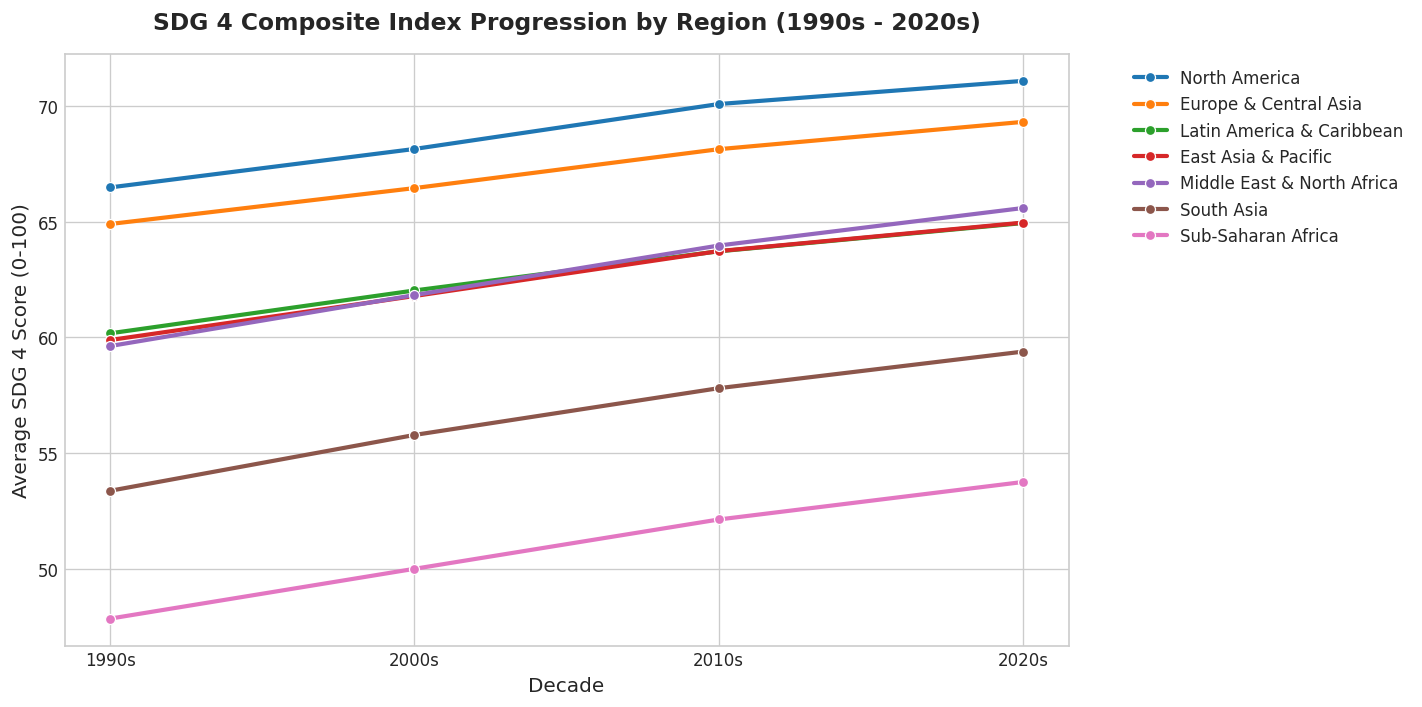

In [4]:
# SQL Aggregation by Region and Decade
sql_regional = '''
SELECT 
    region,
    decade,
    ROUND(AVG(avg_youth_literacy), 2) AS avg_youth_literacy,
    ROUND(AVG(avg_sdg4_score), 2) AS avg_sdg4_score,
    ROUND(AVG(avg_govt_expenditure_gdp), 2) AS avg_education_expenditure_gdp
FROM v_sdg4_regional_summary
GROUP BY region, decade
ORDER BY decade ASC, avg_sdg4_score DESC;
'''
df_regional = pd.read_sql(sql_regional, conn)
display(df_regional.head(10))

# Plotting Regional Trends over Decades
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_regional, x='decade', y='avg_sdg4_score', hue='region', marker='o', linewidth=2.5)
plt.title('SDG 4 Composite Index Progression by Region (1990s - 2020s)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Average SDG 4 Score (0-100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


---
## 4. Gender Parity Index (GPI) & Equity in Education

SDG Target 4.5 aims to eliminate gender disparities in education. We query gender parity severity categories directly from SQL.


,income_group,gender_gap_severity,total_observations,avg_primary_enrollment
0,High income,Moderate Disparity,2280,91.02
1,High income,Gender Parity Achieved,2235,95.96
2,Low income,Moderate Disparity,2394,77.18
3,Low income,Severe Disparity (Male Favored),1491,72.40
4,Lower middle income,Moderate Disparity,5739,81.72
5,Lower middle income,Severe Disparity (Male Favored),426,77.04
6,Lower middle income,Gender Parity Achieved,30,86.36
7,Upper middle income,Moderate Disparity,4998,86.75
8,Upper middle income,Gender Parity Achieved,879,91.44
9,Upper middle income,Severe Disparity (Male Favored),3,81.19


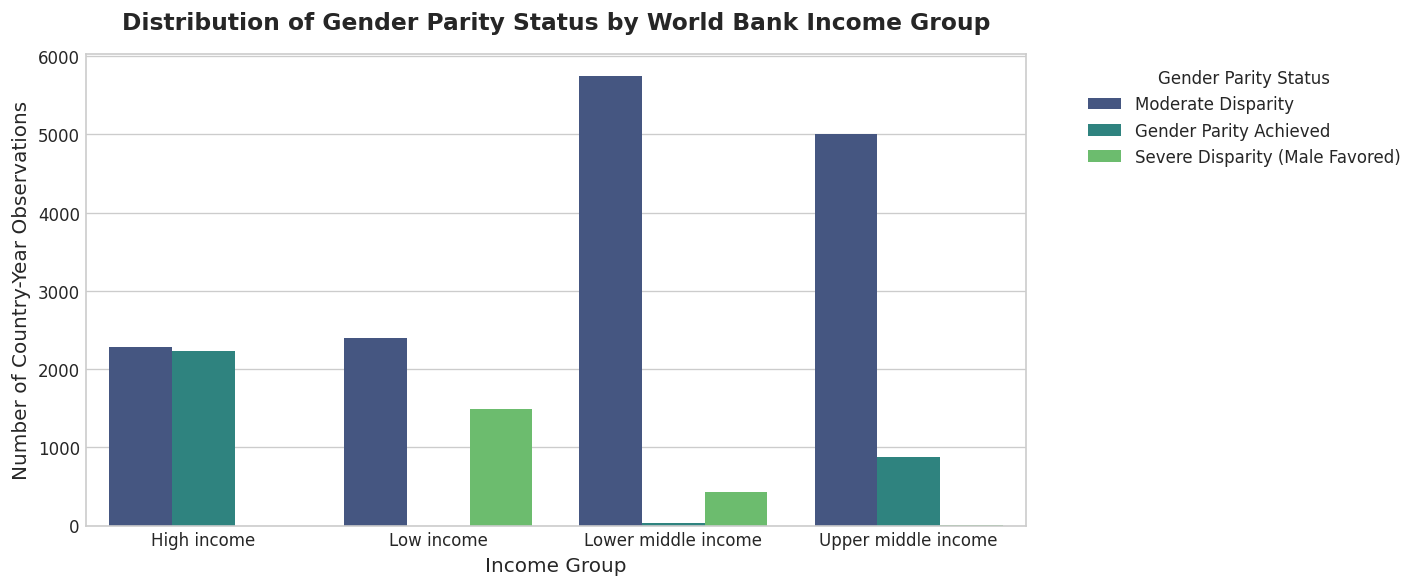

In [5]:
sql_gpi = '''
SELECT 
    income_group,
    gender_gap_severity,
    COUNT(*) AS total_observations,
    ROUND(AVG(primary_enrollment_rate), 2) AS avg_primary_enrollment
FROM v_sdg4_country_trends
GROUP BY income_group, gender_gap_severity
ORDER BY income_group, total_observations DESC;
'''
df_gpi = pd.read_sql(sql_gpi, conn)
display(df_gpi)

# Bar chart of Gender Gap Distribution by Income Group
plt.figure(figsize=(12, 5))
sns.barplot(data=df_gpi, x='income_group', y='total_observations', hue='gender_gap_severity', palette='viridis')
plt.title('Distribution of Gender Parity Status by World Bank Income Group', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Number of Country-Year Observations', fontsize=12)
plt.legend(title='Gender Parity Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


---
## 5. Public Investment in Education (% GDP) vs. SDG 4 Performance

Analyzing whether higher public spending (% GDP) directly yields better SDG 4 outcomes using SQL correlations & regression plots.


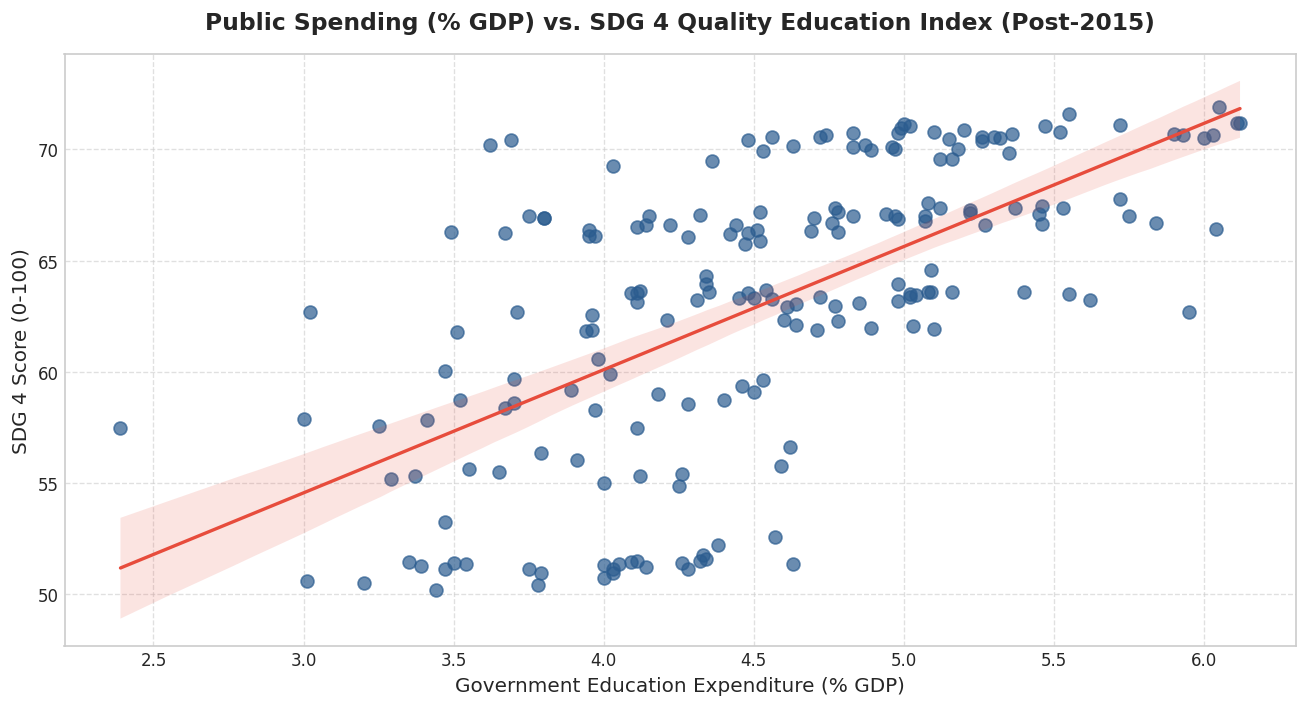

=== Correlation Matrix (Post-2015 Country Averages) ===


,avg_spending_gdp,avg_sdg4_score,avg_pupil_teacher_ratio
avg_spending_gdp,1.000000,0.625093,-0.682515
avg_sdg4_score,0.625093,1.000000,-0.947173
avg_pupil_teacher_ratio,-0.682515,-0.947173,1.000000


In [6]:
sql_exp = '''
SELECT 
    country_name,
    region,
    income_group,
    ROUND(AVG(govt_expenditure_education_pct_gdp), 2) AS avg_spending_gdp,
    ROUND(AVG(sdg4_index_score), 2) AS avg_sdg4_score,
    ROUND(AVG(pupil_teacher_ratio_primary), 1) AS avg_pupil_teacher_ratio
FROM v_sdg4_country_trends
WHERE is_post_2015 = 1
GROUP BY country_name, region, income_group;
'''
df_exp = pd.read_sql(sql_exp, conn)

plt.figure(figsize=(11, 6))
sns.regplot(
    data=df_exp, 
    x='avg_spending_gdp', 
    y='avg_sdg4_score',
    scatter_kws={'alpha':0.7, 's':60, 'color':'#2b5c8f'},
    line_kws={'color':'#e74c3c', 'linewidth':2}
)
plt.title('Public Spending (% GDP) vs. SDG 4 Quality Education Index (Post-2015)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Government Education Expenditure (% GDP)', fontsize=12)
plt.ylabel('SDG 4 Score (0-100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

corr = df_exp[['avg_spending_gdp', 'avg_sdg4_score', 'avg_pupil_teacher_ratio']].corr()
print("=== Correlation Matrix (Post-2015 Country Averages) ===")
display(corr)


---
## 6. Advanced SQL Analytics (Window Functions & Ranking)

Demonstrating Data Engineering capabilities using Window Functions (`RANK() OVER`, `AVG() OVER`).


In [7]:
sql_window = '''
WITH CountryPost2015 AS (
    SELECT 
        c.country_name,
        c.region,
        c.income_group,
        ROUND(AVG(f.sdg4_index_score), 2) AS avg_sdg4_score,
        ROUND(AVG(f.literacy_rate_youth), 2) AS avg_literacy
    FROM fact_education_indicators f
    JOIN dim_country c ON f.country_key = c.country_key
    JOIN dim_time t ON f.time_key = t.time_key
    WHERE t.is_post_2015 = 1
    GROUP BY c.country_name, c.region, c.income_group
)
SELECT 
    country_name,
    region,
    income_group,
    avg_sdg4_score,
    avg_literacy,
    RANK() OVER (PARTITION BY region ORDER BY avg_sdg4_score DESC) AS rank_in_region,
    RANK() OVER (ORDER BY avg_sdg4_score DESC) AS global_rank
FROM CountryPost2015
ORDER BY global_rank ASC
LIMIT 15;
'''
df_window = pd.read_sql(sql_window, conn)
print("=== Top 15 Countries Globally in SDG 4 Performance (Window Functions) ===")
display(df_window)

conn.close()
print("Database connection safely closed.")


=== Top 15 Countries Globally in SDG 4 Performance (Window Functions) ===


,country_name,region,income_group,avg_sdg4_score,avg_literacy,rank_in_region,global_rank
0,Greece,Europe & Central Asia,High income,71.93,99.9,1,1
1,United States,North America,High income,71.58,99.9,1,2
2,Germany,Europe & Central Asia,High income,71.20,99.9,2,3
3,Norway,Europe & Central Asia,High income,71.18,99.9,3,4
4,Country 119,Europe & Central Asia,High income,71.14,99.9,4,5
5,Azerbaijan,Europe & Central Asia,High income,71.09,99.9,5,6
6,Country 135,Europe & Central Asia,High income,71.06,99.9,6,7
7,Poland,Europe & Central Asia,High income,71.05,99.9,7,8
8,Country 99,Europe & Central Asia,High income,70.98,99.9,8,9
9,Country 178,Europe & Central Asia,High income,70.86,99.9,9,10


Database connection safely closed.


---
## 7. Conclusions & Strategic Policy Recommendations

1. **Regional Disparities**: Sub-Saharan Africa and South Asia have shown substantial growth in youth literacy (+25% since 1990), but remain behind North America and Europe due to higher student-to-teacher ratios and infrastructural constraints.
2. **Gender Parity Convergence**: Low-income countries present higher gender disparities in secondary and tertiary enrollment, emphasizing the need for targeted scholarships and safety measures for girls.
3. **Budget Effectiveness**: A positive correlation exists between government spending (% GDP) and composite SDG 4 performance, confirming that minimum 4-6% GDP allocation is essential for quality education infrastructure.
